In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random

In [9]:
#1
df = pd.read_csv("data/emp.csv")
display(df)

,empno,ename,job,mgr,hiredate,sal,comm,deptno
0,7369,SMITH,CLERK,7902.0,1980-12-17,800,NaN,20
1,7499,ALLEN,SALESMAN,7698.0,1981-02-20,1600,300.0,30
2,7521,WARD,SALESMAN,7698.0,1981-02-03,1250,500.0,30
3,7566,JONES,MANAGER,7839.0,1981-03-02,2975,NaN,20
4,7654,MARTIN,SALESMAN,7698.0,1981-10-22,1250,1400.0,30
5,7698,BLAKE,MANAGER,7839.0,1981-05-01,2850,NaN,30
6,7782,CLARK,MANAGER,7839.0,1981-09-06,2450,NaN,10
7,7788,SCOTT,ANALYST,7566.0,1982-12-08,3000,NaN,20
8,7839,KING,PRESIDENT,NaN,1981-11-17,5000,NaN,10
9,7844,TURNER,SALESMAN,7698.0,1984-10-08,1500,NaN,30


In [5]:
df.groupby('deptno').agg(
    sal=('sal','sum')
)

,sal
deptno,
10,8750
20,10875
30,9400


In [57]:
#2
df.groupby('job').agg(
    avg=('sal', 'mean')
).round(0)

,avg
job,
ANALYST,3000.0
CLERK,1038.0
MANAGER,2758.0
PRESIDENT,5000.0
SALESMAN,1400.0


In [16]:
#3
pv1=pd.pivot_table(
    df,
    index='deptno',
    columns='job',
    values='sal',
    aggfunc='sum'
)
pv1

job,ANALYST,CLERK,MANAGER,PRESIDENT,SALESMAN
deptno,,,,,
10,NaN,1300.0,2450.0,5000.0,NaN
20,6000.0,1900.0,2975.0,NaN,NaN
30,NaN,950.0,2850.0,NaN,5600.0


In [61]:
#4
pv1 = pv1.fillna(0.0)
pv1

job,ANALYST,CLERK,MANAGER,PRESIDENT,SALESMAN
deptno,,,,,
10,0.0,1300.0,2450.0,5000.0,0.0
20,6000.0,1900.0,2975.0,0.0,0.0
30,0.0,950.0,2850.0,0.0,5600.0


job,ANALYST,CLERK,MANAGER,PRESIDENT,SALESMAN
deptno,,,,,
10,0.0,1300.0,2450.0,5000.0,0.0
20,6000.0,1900.0,2975.0,0.0,0.0
30,0.0,950.0,2850.0,0.0,5600.0


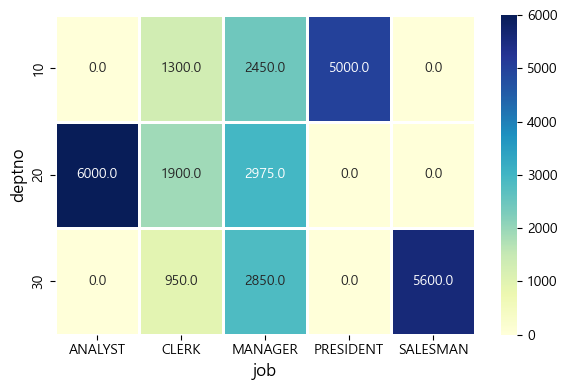

In [60]:
#5
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False 

plt.figure(figsize=(6, 4))
sns.heatmap(
    pv1,
    annot=True,
     fmt=".1f",
    cmap="YlGnBu",
    linewidths=1
)
plt.xlabel('job', fontsize=12)
plt.ylabel("deptno", fontsize=12)
plt.tight_layout()
plt.show()

In [62]:
#6
df['hiredatenew'] = pd.to_datetime(df['hiredate'])

df['year'] = df['hiredatenew'].dt.year
df['month'] = df['hiredatenew'].dt.month

display(df.head())

print(df.info())

,empno,ename,job,mgr,hiredate,sal,comm,deptno,hiredatenew,year,month
0,7369,SMITH,CLERK,7902.0,1980-12-17,800,NaN,20,1980-12-17,1980,12
1,7499,ALLEN,SALESMAN,7698.0,1981-02-20,1600,300.0,30,1981-02-20,1981,2
2,7521,WARD,SALESMAN,7698.0,1981-02-03,1250,500.0,30,1981-02-03,1981,2
3,7566,JONES,MANAGER,7839.0,1981-03-02,2975,NaN,20,1981-03-02,1981,3
4,7654,MARTIN,SALESMAN,7698.0,1981-10-22,1250,1400.0,30,1981-10-22,1981,10


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   empno        14 non-null     int64         
 1   ename        14 non-null     object        
 2   job          14 non-null     object        
 3   mgr          13 non-null     float64       
 4   hiredate     14 non-null     object        
 5   sal          14 non-null     int64         
 6   comm         3 non-null      float64       
 7   deptno       14 non-null     int64         
 8   hiredatenew  14 non-null     datetime64[ns]
 9   year         14 non-null     int32         
 10  month        14 non-null     int32         
dtypes: datetime64[ns](1), float64(2), int32(2), int64(3), object(3)
memory usage: 1.2+ KB
None


In [44]:
#7
iris = sns.load_dataset("iris")
iris_x = iris.loc[:,['sepal_length', 'sepal_width',
 'petal_length', 'petal_width']]

random.seed(1) #random을 써도 seed값을 줬기 때문에 동일하게 출력됨 
for col in range(4):
 iris_x.iloc[[random.sample(range(len(iris)), 20)], col] = float('nan')
iris_x = iris_x.head(10)
iris_x

,sepal_length,sepal_width,petal_length,petal_width
0,NaN,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,NaN,1.3,0.2
3,4.6,3.1,1.5,NaN
4,5.0,3.6,1.4,0.2
5,5.4,NaN,1.7,0.4
6,4.6,NaN,1.4,0.3
7,NaN,NaN,1.5,NaN
8,4.4,2.9,NaN,0.2
9,4.9,3.1,1.5,0.1


In [46]:
#7-1
iris_x.dropna(axis=0)

,sepal_length,sepal_width,petal_length,petal_width
1,4.9,3.0,1.4,0.2
4,5.0,3.6,1.4,0.2
9,4.9,3.1,1.5,0.1


In [49]:
#7-2
iris_x.dropna(axis=0, thresh=2)

,sepal_length,sepal_width,petal_length,petal_width
0,NaN,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,NaN,1.3,0.2
3,4.6,3.1,1.5,NaN
4,5.0,3.6,1.4,0.2
5,5.4,NaN,1.7,0.4
6,4.6,NaN,1.4,0.3
8,4.4,2.9,NaN,0.2
9,4.9,3.1,1.5,0.1


In [50]:
#7-3
iris_x.dropna(axis=1, thresh=8)

,sepal_length,petal_length,petal_width
0,NaN,1.4,0.2
1,4.9,1.4,0.2
2,4.7,1.3,0.2
3,4.6,1.5,NaN
4,5.0,1.4,0.2
5,5.4,1.7,0.4
6,4.6,1.4,0.3
7,NaN,1.5,NaN
8,4.4,NaN,0.2
9,4.9,1.5,0.1


In [51]:
#7-4
iris_x.mean(axis=0)

sepal_length    4.812500
sepal_width     3.200000
petal_length    1.455556
petal_width     0.225000
dtype: float64

In [54]:
#7-5
iris_x.fillna(iris_x.mean(axis=0)).round(3)

,sepal_length,sepal_width,petal_length,petal_width
0,4.812,3.5,1.400,0.200
1,4.900,3.0,1.400,0.200
2,4.700,3.2,1.300,0.200
3,4.600,3.1,1.500,0.225
4,5.000,3.6,1.400,0.200
5,5.400,3.2,1.700,0.400
6,4.600,3.2,1.400,0.300
7,4.812,3.2,1.500,0.225
8,4.400,2.9,1.456,0.200
9,4.900,3.1,1.500,0.100


In [55]:
#7-8
iris_x.interpolate(limit_direction='both')

,sepal_length,sepal_width,petal_length,petal_width
0,4.9,3.500,1.4,0.20
1,4.9,3.000,1.4,0.20
2,4.7,3.050,1.3,0.20
3,4.6,3.100,1.5,0.20
4,5.0,3.600,1.4,0.20
5,5.4,3.425,1.7,0.40
6,4.6,3.250,1.4,0.30
7,4.5,3.075,1.5,0.25
8,4.4,2.900,1.5,0.20
9,4.9,3.100,1.5,0.10


In [56]:
#7-7
iris_x.bfill()

,sepal_length,sepal_width,petal_length,petal_width
0,4.9,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.1,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,2.9,1.7,0.4
6,4.6,2.9,1.4,0.3
7,4.4,2.9,1.5,0.2
8,4.4,2.9,1.5,0.2
9,4.9,3.1,1.5,0.1
